# Learning tables from data: calibration, identification and the Jacobian's pattern

A table need not be fixed when the code is generated. Its values can be decision variables,
fitted to measurements. Or a spline's coefficients can be the parameters of a model identified
from data. `interp` takes an `Expr` wherever it takes numbers, and differentiates through it.

This notebook:

- calibrates a lookup table from scattered measurements;
- identifies a Hammerstein model whose static nonlinearity is a spline;
- shows why the points at which a table is read matter as much as the table: they decide the
  Jacobian's sparsity pattern, and with it the solver's cost.

The same two problems are the CasADi pairs `pairs/table_calibration` and
`pairs/hammerstein_sysid`.

| Scaly feature | Where |
| --- | --- |
| `interp.interpolant` over an `Expr` table; `at()` at points known now | calibration |
| `BSpline.basis` (the design matrix) | the least-squares reference |
| a table as a Function input; the header's layout comment | the calibrated lookup |
| `sc.jacobian_sparsity` | the Jacobian's pattern |
| `interp.BSpline` with `Expr` coefficients inside a `scan` | the Hammerstein model |

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import BSpline as SciBSpline
from scipy.optimize import least_squares

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
sys.path.insert(0, str(Path.cwd() / "pairs"))  # the data the CasADi pairs use
import plotstyle
from _data import HAMMERSTEIN_KNOTS, calibration_data, hammerstein_data
import scaly as sc
from scaly import interp
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "interp" / "learning_tables"

## Calibrating a table from scattered measurements

A bilinear 12 x 12 table on $[0, 1]^2$ is fitted to 3 000 noisy measurements (noise 0.005) of
an efficiency-like map at random points:

$$\min_T \sum_i \left(T(p_i) - z_i\right)^2 .$$

The table's values are the variables. The points are known when the problem is built, so
`at(points)` reads the table there as one sparse product: the design matrix, four entries per
row (the corners of each point's cell), times the table. The problem is linear least squares,
which IPOPT solves in one Newton step. The reference is NumPy's `lstsq` on the same design
matrix, which `basis(points)` returns.

In [2]:
grid, points, measured, truth = calibration_data()
n = grid.size


@sc.opt.problem(vars=sc.L("T", (n, n)))
def calibrate(T):
  residual = interp.interpolant((grid, grid), T, kind="linear").at(points) - measured
  return sc.opt.ProblemSpec(minimize=(residual**2).sum())


solve = sc.opt.solver(calibrate, sc.opt.IPOPT(options={"print_level": 0, "sb": "yes", "tol": 1e-12}))
table, *_ = solve(np.zeros((n, n)), np.zeros((n, n)), np.zeros(0), np.zeros(0), ())
stats = sc.opt.solver_stats(solve)

design = interp.interpolant((grid, grid), np.zeros((n, n)), kind="linear").basis(points)  # (3000, 144), sparse
lstsq = np.linalg.lstsq(design.toarray(), measured, rcond=None)[0].reshape(n, n)
print(f"IPOPT: {stats.iter} iteration(s), {1e3 * stats.t_total:.2f} ms")
print(f"the design matrix has {design.nnz} nonzeros, {design.nnz / design.shape[0]:.0f} per row")
print(f"against NumPy's lstsq on the design matrix: {np.abs(table - lstsq).max():.1e}")
print(f"the calibrated table against the truth at the grid: max {np.abs(table - truth).max():.4f}, rms {np.sqrt(np.mean((table - truth) ** 2)):.4f} (noise 0.005)")

IPOPT: 1 iteration(s), 1.59 ms
the design matrix has 12000 nonzeros, 4 per row
against NumPy's lstsq on the design matrix: 5.6e-15
the calibrated table against the truth at the grid: max 0.0080, rms 0.0022 (noise 0.005)


calibrated_lookup.c: 104 lines; the table is an input:
typedef struct { SCALY_ALIGNAS(16) double data[144]; } calibrated_lookup_table_t;  // 12 x 12, row-major (C order)


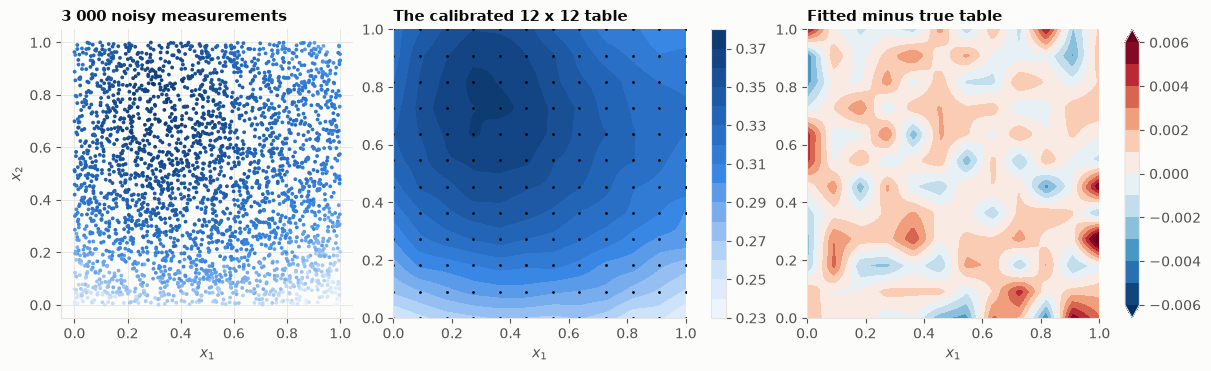

In [3]:
# The calibrated table as a run-time input: one compiled lookup serves the truth and the fit.
@sc.function(sc.L("p", 2), sc.L("table", (n, n)), output="value", name="calibrated_lookup")
def lookup(p, table_in):
  return interp.interpolant((grid, grid), table_in, kind="linear")(p)


fine = np.linspace(0.0, 1.0, 121)
F = np.stack(np.meshgrid(fine, fine, indexing="ij"), axis=-1).reshape(-1, 2)
fitted = np.array([float(lookup(p, table)) for p in F]).reshape(121, 121)
reference = np.array([float(lookup(p, truth)) for p in F]).reshape(121, 121)
module = write_module(lookup, GENERATED / "lookup")
print(f"{module.source_name}: {len(module.source.splitlines())} lines; the table is an input:")
print("\n".join(line for line in module.header.splitlines() if "calibrated_lookup_table_t" in line and "typedef" in line))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].scatter(points[:, 0], points[:, 1], c=measured, s=3, cmap=plotstyle.BLUES)
axes[0].set_title("3 000 noisy measurements")
c1 = axes[1].contourf(fine, fine, fitted.T, levels=14, cmap=plotstyle.BLUES)
axes[1].plot(*np.meshgrid(grid, grid, indexing="ij"), "k.", ms=2)
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("The calibrated 12 x 12 table")
c2 = axes[2].contourf(fine, fine, (fitted - reference).T, levels=np.linspace(-0.006, 0.006, 13), cmap="RdBu_r", extend="both")
fig.colorbar(c2, ax=axes[2])
axes[2].set_title("Fitted minus true table")
for ax in axes:
  ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
plt.show()

IPOPT's table equals the least-squares solution to $6 \times 10^{-15}$. About twenty measurements
inform each value, so the fit lies within 0.0022 of the true table in rms, less than half the
noise, and within 0.008 everywhere. What remains is noise the averaging leaves (right). It is
largest at the edges and corners, where fewer measurements surround each value.

The fitted table then goes into generated code as an input of a compiled lookup. The same
104 lines of C read the truth and the fit alike, and the header gives the buffer's layout.

In CasADi a parametric `interpolant` (its data an input) has a zero derivative with respect to
that data unless it is built with `inline=True`. The pair `pairs/table_calibration` shows the
consequence: without it, IPOPT stops at the initial point after 0 iterations, reports
`Solve_Succeeded`, and leaves the table at zero.

## The Jacobian's pattern: points known now against symbolic points

Where the table is read decides which of its values each residual depends on:

- **known points**: `at(points)` knows each point's cell when the graph is built, so the pattern
  is exact: 4 values per residual for a bilinear table, 16 for a bicubic B-spline's coefficients;
- **symbolic points**: points that are variables or parameters, found in their cells only at
  run time. Every residual may then depend on every value, and the pattern is dense;
- **an interpolating cubic**: dense even at known points. Its fit is global, each coefficient a
  combination of every value.

To fit a smooth table, make the B-spline's coefficients the variables, as `interp.BSpline` or
`interp.smoothing` do, rather than the values of an interpolating cubic.

In [4]:
T = sc.sym("T", (n, n))
P = sc.sym("P", points.shape)
patterns = {
  "bilinear table, at() of known points": interp.interpolant((grid, grid), T, kind="linear").at(points),
  "bilinear table, symbolic points": interp.interpolant((grid, grid), T, kind="linear")(P),
  "bicubic B-spline coefficients, at()": interp.BSpline((np.r_[[0.0] * 3, np.linspace(0.0, 1.0, 10), [1.0] * 3],) * 2, T, 3).at(points),
  "interpolating bicubic, at()": interp.interpolant((grid, grid), T, kind="cubic").at(points),
}
pattern_rows = []
for label, residual in patterns.items():
  sparsity = sc.jacobian_sparsity(residual, T)
  pattern_rows.append((label, len(sparsity.rows), len(sparsity.rows) / points.shape[0]))
  print(f"{label:40s} {len(sparsity.rows):>7d} nonzeros, {len(sparsity.rows) / points.shape[0]:5.1f} per row")

bilinear table, at() of known points       12000 nonzeros,   4.0 per row
bilinear table, symbolic points           432000 nonzeros, 144.0 per row
bicubic B-spline coefficients, at()        48000 nonzeros,  16.0 per row


interpolating bicubic, at()               432000 nonzeros, 144.0 per row


In [5]:
# What the pattern costs a solver: the same calibration with the points as a parameter of the problem.
@sc.opt.problem(vars=sc.L("T", (n, n)), params=sc.L("P", points.shape))
def calibrate_symbolic(T, P):
  residual = interp.interpolant((grid, grid), T, kind="linear")(P) - measured
  return sc.opt.ProblemSpec(minimize=(residual**2).sum())


solve_symbolic = sc.opt.solver(calibrate_symbolic, sc.opt.IPOPT(options={"print_level": 0, "sb": "yes", "tol": 1e-12}))
table_symbolic, *_ = solve_symbolic(np.zeros((n, n)), np.zeros((n, n)), np.zeros(0), np.zeros(0), points)
timings = {}
for label, (fn, args) in {
  "known points": (solve, ()),
  "symbolic points": (solve_symbolic, points),
}.items():
  best = np.inf
  for _ in range(5):
    t0 = time.perf_counter()
    fn(np.zeros((n, n)), np.zeros((n, n)), np.zeros(0), np.zeros(0), args)
    best = min(best, time.perf_counter() - t0)
  timings[label] = 1e3 * best
print(f"the two solutions agree to {np.abs(table_symbolic - table).max():.1e}")
print(", ".join(f"{k}: {v:.1f} ms per solve" for k, v in timings.items()))

the two solutions agree to 8.9e-16
known points: 0.9 ms per solve, symbolic points: 19.8 ms per solve


The same calibration with the points as a parameter of the problem gives the same table, to
$10^{-15}$. Its dense Jacobian (432 000 entries against 12 000) makes each solve about 20 times
slower. When the points are known, pass them as numbers.

## Identifying a Hammerstein model

A Hammerstein model is a static nonlinearity followed by linear dynamics:

$$v_k = N(u_k), \qquad y_{k+1} = a_1 y_k + a_2 y_{k-1} + v_k .$$

Here $N$ is a cubic B-spline with 20 coefficients $c$ on $[-1, 1]$, and the data are 2 000
samples of such a system: an input holding random levels, and the output measured with noise
0.01. The true curve is $\tanh 2u + 0.3 u^3$. Identification fits $(a_1, a_2, c)$ by single
shooting. The 2 000 steps are one `scan`, and the spline sits inside its step with the
coefficients an `Expr` broadcast into every iteration.

The guess is a first-order model with the identity as nonlinearity. The references are SciPy's
`least_squares` (Levenberg-Marquardt, with a finite-difference Jacobian) on a NumPy simulation
of the same model, and central differences for the gradient of the cost.

In [6]:
data = hammerstein_data()
steps = data["u"].size


@sc.function(2, 1, 2, 20, output=sc.G("xnext", "y"))
def step(x, u, a, c):
  y = a[0] * x[0] + a[1] * x[1] + interp.BSpline(HAMMERSTEIN_KNOTS, c, 3)(u[0])
  return sc.stack([y, x[0]]), sc.stack([y])


@sc.function(2, 20, output="residual", name="hammerstein_residual")
def residual(a, c):
  _, y = sc.scan(step, sc.const(np.zeros(2)), [(sc.const(data["u"]), 0, 1), (a, 0, 0), (c, 0, 0)], length=steps)
  return y - data["y"]


@sc.opt.problem(vars=sc.G(sc.L("a", 2), sc.L("c", 20)))
def sysid(theta):
  a, c = theta
  r = residual(a, c)
  return sc.opt.ProblemSpec(minimize=(r**2).sum())


identify = sc.opt.solver(sysid, sc.opt.IPOPT(options={"print_level": 0, "sb": "yes", "tol": 1e-12}))
(a_fit, c_fit), *_ = identify((data["a_guess"], data["c_guess"]), (np.zeros(2), np.zeros(20)), np.zeros(0), np.zeros(0), ())
id_stats = sc.opt.solver_stats(identify)
print(f"IPOPT: {id_stats.iter} iterations, {1e3 * id_stats.t_total:.1f} ms; a = {np.array2string(a_fit, precision=5)} (true {data['a_true']})")


# The reference: SciPy's least_squares on a NumPy simulation, its Jacobian by finite differences.
def simulate(theta):
  a, c = theta[:2], theta[2:]
  v = SciBSpline(HAMMERSTEIN_KNOTS, c, 3)(data["u"])
  y, prev, out = 0.0, 0.0, np.empty(steps)
  for k in range(steps):
    y, prev = a[0] * y + a[1] * prev + v[k], y
    out[k] = y
  return out - data["y"]


theta0 = np.concatenate([data["a_guess"], data["c_guess"]])
started = time.perf_counter()
with np.errstate(over="ignore", invalid="ignore"):  # a trial step can make the dynamics unstable; it is rejected
  ref = least_squares(simulate, theta0, jac="3-point", method="lm", xtol=1e-15, ftol=1e-15, gtol=1e-15)
scipy_ms = 1e3 * (time.perf_counter() - started)
theta_fit = np.concatenate([a_fit, c_fit])
print(f"SciPy least_squares: {ref.nfev} residual evaluations, {scipy_ms:.0f} ms; parameters agree to {np.abs(ref.x - theta_fit).max():.1e}")

# The gradient of the cost at the initial guess against central differences.
cost_grad = sc.function(sc.L("theta", 22), output="g", name="hammerstein_cost_grad")(
  lambda th: sc.gradient((residual(th[:2], th[2:]) ** 2).sum(), th)
)
g = np.asarray(cost_grad(theta0))
h = 1e-6
fd = np.array([((simulate(theta0 + h * e) ** 2).sum() - (simulate(theta0 - h * e) ** 2).sum()) / (2 * h) for e in np.eye(22)])
grad_error = float(np.abs(g - fd).max() / np.abs(fd).max())
print(f"the gradient at the guess against central differences: {grad_error:.1e} relative")

IPOPT: 13 iterations, 16.9 ms; a = [ 1.50001 -0.7    ] (true [ 1.5 -0.7])
SciPy least_squares: 13 residual evaluations, 201 ms; parameters agree to 1.4e-12


the gradient at the guess against central differences: 3.3e-11 relative


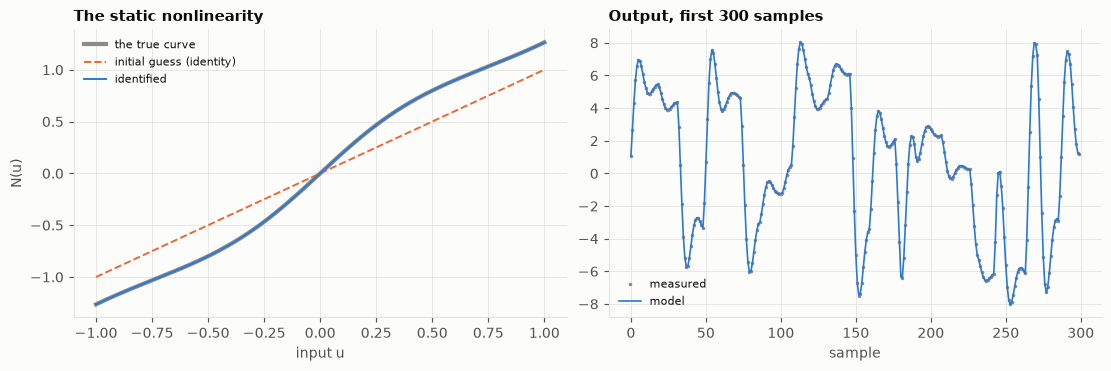

output residual rms 0.0099 (noise 0.01); identified curve against the generating spline: max 0.0005


In [7]:
u_line = np.linspace(-1.0, 1.0, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.plot(u_line, np.tanh(2.0 * u_line) + 0.3 * u_line**3, color=plotstyle.NEUTRAL, lw=3, label="the true curve")
ax1.plot(u_line, SciBSpline(HAMMERSTEIN_KNOTS, data["c_guess"], 3)(u_line), "--", color=plotstyle.ORANGE, lw=1.4, label="initial guess (identity)")
ax1.plot(u_line, SciBSpline(HAMMERSTEIN_KNOTS, c_fit, 3)(u_line), color=plotstyle.BLUE, lw=1.4, label="identified")
ax1.set_xlabel("input u")
ax1.set_ylabel("N(u)")
ax1.set_title("The static nonlinearity")
ax1.legend(fontsize=8)
window = slice(0, 300)
y_fit = simulate(theta_fit) + data["y"]
ax2.plot(data["y"][window], ".", color=plotstyle.NEUTRAL, ms=3, label="measured")
ax2.plot(y_fit[window], color=plotstyle.BLUE, lw=1.2, label="model")
ax2.set_xlabel("sample")
ax2.set_title("Output, first 300 samples")
ax2.legend(fontsize=8)
plt.show()
rms = float(np.sqrt(np.mean((y_fit - data["y"]) ** 2)))
curve_error = float(np.abs(SciBSpline(HAMMERSTEIN_KNOTS, c_fit, 3)(u_line) - SciBSpline(HAMMERSTEIN_KNOTS, data["c_true"], 3)(u_line)).max())
print(f"output residual rms {rms:.4f} (noise 0.01); identified curve against the generating spline: max {curve_error:.4f}")

IPOPT converges in 13 iterations, 17 ms. SciPy's Levenberg-Marquardt reaches the same parameters
to $10^{-12}$ in about 200 ms. The gradient of the cost agrees with central differences to
$3 \times 10^{-11}$. The dynamics come back to five digits, and the output residual (0.0099 rms)
is the noise (0.01). The identified curve is within $5 \times 10^{-4}$ of the spline that
generated the data, and follows the true curve to the spline's resolution.

CasADi's `bspline` node with symbolic coefficients has the same trap as its parametric
interpolant: its derivative in the coefficients is zero unless it is built with `inline=True`.
`pairs/hammerstein_sysid` builds it inlined. There both sides take the same 13 iterations, and
`examples/interp/README.md` compares their times.

## Checks

In [8]:
assert np.abs(table - lstsq).max() < 1e-10 and np.abs(table_symbolic - table).max() < 1e-10
assert np.sqrt(np.mean((table - truth) ** 2)) < 0.005
rows = {label: per_row for label, _, per_row in pattern_rows}
assert rows["bilinear table, at() of known points"] == 4 and rows["bicubic B-spline coefficients, at()"] == 16
assert rows["bilinear table, symbolic points"] == rows["interpolating bicubic, at()"] == n * n
assert timings["symbolic points"] > 3 * timings["known points"]
assert np.abs(ref.x - theta_fit).max() < 1e-6 and grad_error < 1e-6
assert abs(a_fit - data["a_true"]).max() < 1e-3 and rms < 0.0105
print("all 7 checks passed")

all 7 checks passed
